#### Analysis for Instagram Data


### Instagram Dataset Field Description  
---  
- Below is a description of the column fields in the dataset:  
---  
#### Core Fields  
- **`Impressions`**: Total number of times the post appeared.
- **`From_Home`**: number of impressions coming from users home feed.
- **`From_Hashtags`**: impressions generated through hashtags.  
- **`From_Explore`**: impressions coming from Instagram Explore page.  
- **`From_Other`**:impressions coming from other sources .
- **`Saves`**: number of users who saved the post.  
- **`Comments`**: total number of comments on the post.  
- **`Shares`**: number of times the post was shared.  
- **`Likes`**: total number of likes received.  
- **`Profile_Visits`**: number of users who visited the profile from this post.  
- **`Follows`**: number of followers gained from this post.  
- **`Caption`**: the text caption written for the post.  
- **`Hashtags`**: list of hashtags used in the post.   

### Question

- What is the nature of the data in the Instagram dataset?
- Are there any missing values? How should we handle them?
- Are there duplicated rows in the dataset?
- What are the data types of each column, and do any need conversion?
- Are there any invalid or out-of-range values?
- Do any columns need renaming to improve clarity?
- Are there inconsistencies in text formatting?
- Are there unnecessary columns that should be removed?
- Can we extract new features to support analysis?
- Is the dataset now fully cleaned and ready for EDA?


###  EDA / Visualization Questions

Below is a set of questions to explore insights and generate visualizations.

- Which posts receive the highest number of likes?
- What is the relationship between likes and comments?
- Does caption length influence engagement?
- What are the most frequently used hashtags?
- the best source of Impressions
- Does the length of a hashtag affect engagement with a post?
- What is the relationship between likes and comments?
- Which posts receive the highest number of likes?
- What is the relationship between Total_Engagements and follows ?


 

#### Data Wrangling

In [1]:
# load needed modules 
import pandas as pd 
import collections

In [2]:
# display all the columns
pd.options.display.max_columns = None

In [3]:
# Load the dataset into datframe 
df = pd.read_csv("Instagram data.csv", encoding="cp1252")

In [4]:
df.head(2)

,Impressions,From Home,From Hashtags,From Explore,From Other,Saves,Comments,Shares,Likes,Profile Visits,Follows,Caption,Hashtags
0,3920,2586,1028,619,56,98,9,5,162,35,2,Here are some of the most important data visua...,#finance #money #business #investing #investme...
1,5394,2727,1838,1174,78,194,7,14,224,48,10,Here are some of the best data science project...,#healthcare #health #covid #data #datascience ...


In [5]:
# print the data shape
df.shape

(119, 13)

- we found that our data contain 119 posts and 13 features

In [6]:
# investigate data properties 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119 entries, 0 to 118
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Impressions     119 non-null    int64 
 1   From Home       119 non-null    int64 
 2   From Hashtags   119 non-null    int64 
 3   From Explore    119 non-null    int64 
 4   From Other      119 non-null    int64 
 5   Saves           119 non-null    int64 
 6   Comments        119 non-null    int64 
 7   Shares          119 non-null    int64 
 8   Likes           119 non-null    int64 
 9   Profile Visits  119 non-null    int64 
 10  Follows         119 non-null    int64 
 11  Caption         119 non-null    object
 12  Hashtags        119 non-null    object
dtypes: int64(11), object(2)
memory usage: 12.2+ KB


-There are no missing values  
-The data types are correct   
-All columns are read properly   
-It is recommended to rename the columns that contain spaces

In [7]:
df_copy = df.copy()

In [8]:
# check for duplicates 
df.duplicated().sum()

np.int64(17)

In [9]:
#remove duplicates
df.drop_duplicates(inplace=True)

In [10]:
# print the data shape after duplicates
df.shape

(102, 13)

In [11]:
# Rename all column names by replacing spaces with underscores 
df.columns = df.columns.str.replace(" ", "_")

In [12]:
df.columns

Index(['Impressions', 'From_Home', 'From_Hashtags', 'From_Explore',
       'From_Other', 'Saves', 'Comments', 'Shares', 'Likes', 'Profile_Visits',
       'Follows', 'Caption', 'Hashtags'],
      dtype='object')

In [13]:
df.isnull().sum()

Impressions       0
From_Home         0
From_Hashtags     0
From_Explore      0
From_Other        0
Saves             0
Comments          0
Shares            0
Likes             0
Profile_Visits    0
Follows           0
Caption           0
Hashtags          0
dtype: int64

In [14]:
df.describe()

,Impressions,From_Home,From_Hashtags,From_Explore,From_Other,Saves,Comments,Shares,Likes,Profile_Visits,Follows
count,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000
mean,5920.254902,2496.911765,1968.284314,1178.568627,184.549020,156.549020,6.352941,9.303922,176.823529,54.666667,22.823529
std,5139.888111,1588.377397,1977.298128,2797.212621,309.096051,157.770332,3.308097,10.150149,85.151747,93.169954,43.685966
min,1941.000000,1133.000000,116.000000,0.000000,9.000000,22.000000,0.000000,0.000000,72.000000,4.000000,0.000000
25%,3556.000000,1923.750000,753.000000,178.750000,40.250000,70.500000,4.000000,3.000000,122.000000,16.000000,4.000000
50%,4343.500000,2216.000000,1326.000000,337.000000,75.000000,111.000000,6.000000,6.500000,157.500000,24.000000,8.000000
75%,6296.250000,2605.250000,2415.750000,728.500000,218.500000,173.500000,8.000000,13.000000,208.750000,45.750000,18.000000
max,36919.000000,13473.000000,11817.000000,17414.000000,2547.000000,1095.000000,19.000000,75.000000,549.000000,611.000000,260.000000


In [15]:
#there was a mistake in Impressions count 
df['Impressions'] = df['From_Home']+df['From_Hashtags']+df['From_Explore']+df['From_Other']


In [16]:
df.head(2)

,Impressions,From_Home,From_Hashtags,From_Explore,From_Other,Saves,Comments,Shares,Likes,Profile_Visits,Follows,Caption,Hashtags
0,4289,2586,1028,619,56,98,9,5,162,35,2,Here are some of the most important data visua...,#finance #money #business #investing #investme...
1,5817,2727,1838,1174,78,194,7,14,224,48,10,Here are some of the best data science project...,#healthcare #health #covid #data #datascience ...


In [17]:
df.groupby('Impressions')["Likes"].sum().nlargest()

Impressions
32546    549
36640    443
15993    416
17268    416
13655    373
Name: Likes, dtype: int64

In [18]:
df["Total_Engagements"] = df["Likes"] + df["Comments"] + df["Shares"] + df["Saves"]
df["Engagement_Rate"] = df["Total_Engagements"] / df["Impressions"]

df.head(5)

,Impressions,From_Home,From_Hashtags,From_Explore,From_Other,Saves,Comments,Shares,Likes,Profile_Visits,Follows,Caption,Hashtags,Total_Engagements,Engagement_Rate
0,4289,2586,1028,619,56,98,9,5,162,35,2,Here are some of the most important data visua...,#finance #money #business #investing #investme...,274,0.063884
1,5817,2727,1838,1174,78,194,7,14,224,48,10,Here are some of the best data science project...,#healthcare #health #covid #data #datascience ...,439,0.075468
2,3806,2085,1188,0,533,41,11,1,131,62,12,Learn how to train a machine learning model an...,#data #datascience #dataanalysis #dataanalytic...,184,0.048345
3,4326,2700,621,932,73,172,10,7,213,23,8,Here’s how you can write a Python program to d...,#python #pythonprogramming #pythonprojects #py...,402,0.092926
4,2275,1704,255,279,37,96,5,4,123,8,0,Plotting annotations while visualizing your da...,#datavisualization #datascience #data #dataana...,228,0.100220


In [19]:
df["Hashtag_Length"] = df["Hashtags"].str.split().str.len()
df["Caption_Length"] = df["Caption"].str.len()
df.head(5)

,Impressions,From_Home,From_Hashtags,From_Explore,From_Other,Saves,Comments,Shares,Likes,Profile_Visits,Follows,Caption,Hashtags,Total_Engagements,Engagement_Rate,Hashtag_Length,Caption_Length
0,4289,2586,1028,619,56,98,9,5,162,35,2,Here are some of the most important data visua...,#finance #money #business #investing #investme...,274,0.063884,22,112
1,5817,2727,1838,1174,78,194,7,14,224,48,10,Here are some of the best data science project...,#healthcare #health #covid #data #datascience ...,439,0.075468,18,187
2,3806,2085,1188,0,533,41,11,1,131,62,12,Learn how to train a machine learning model an...,#data #datascience #dataanalysis #dataanalytic...,184,0.048345,18,117
3,4326,2700,621,932,73,172,10,7,213,23,8,Here’s how you can write a Python program to d...,#python #pythonprogramming #pythonprojects #py...,402,0.092926,11,202
4,2275,1704,255,279,37,96,5,4,123,8,0,Plotting annotations while visualizing your da...,#datavisualization #datascience #data #dataana...,228,0.100220,29,178


In [20]:
#remove # from hashtag colum 
df['hashtags_clean'] = df['Hashtags'].str.split('#').str[1:]


In [21]:
hashtags_expanded = df.explode("hashtags_clean")


In [22]:
df.sort_values(by='Impressions',ascending=False, inplace=True)
df.reset_index(drop=True,inplace=True)
df.head(5)

,Impressions,From_Home,From_Hashtags,From_Explore,From_Other,Saves,Comments,Shares,Likes,Profile_Visits,Follows,Caption,Hashtags,Total_Engagements,Engagement_Rate,Hashtag_Length,Caption_Length,hashtags_clean
0,36640,13473,4176,16444,2547,653,5,26,443,611,228,175 Python Projects with Source Code solved an...,#python #pythonprogramming #pythonprojects #py...,1127,0.030759,11,79,"[python , pythonprogramming , pythonprojects ,..."
1,32546,11815,3147,17414,170,1095,2,75,549,148,214,Here are some of the best data science certifi...,#datascience #datasciencejobs #datasciencetrai...,1721,0.052879,17,87,"[datascience , datasciencejobs , datasciencetr..."
2,17540,2449,2141,12389,561,504,3,23,308,70,96,Here are some of the best resources to learn S...,#sql #mysql #datascience #datasciencejobs #dat...,838,0.047777,19,66,"[sql , mysql , datascience , datasciencejobs ,..."
3,17268,1817,10008,5192,251,285,7,7,416,467,260,Here is a list of 100+ Machine Learning Algori...,#machinelearning #machinelearningalgorithms #d...,715,0.041406,17,318,"[machinelearning , machinelearningalgorithms ,..."
4,15993,3144,11817,564,468,252,6,20,416,330,94,280 Machine Learning Projects Solved & Explain...,#data #datascience #dataanalysis #dataanalytic...,694,0.043394,17,95,"[data , datascience , dataanalysis , dataanaly..."


In [23]:
df['hashtags_clean']

0      [python , pythonprogramming , pythonprojects ,...
1      [datascience , datasciencejobs , datasciencetr...
2      [sql , mysql , datascience , datasciencejobs ,...
3      [machinelearning , machinelearningalgorithms ,...
4      [data , datascience , dataanalysis , dataanaly...
                             ...                        
97     [datavisualization , datascience , data , data...
98     [neuralnetwork , machinelearning , artificiali...
99     [data , datascience , dataanalysis , dataanaly...
100    [datavisualization , datascience , data , data...
101    [neuralnetwork , machinelearning , artificiali...
Name: hashtags_clean, Length: 102, dtype: object

In [24]:
Hashtags_counts = [y.replace('\xa0', '').strip() for x in df['hashtags_clean']for y in x] 

In [25]:
Hashtags_counts

['python',
 'pythonprogramming',
 'pythonprojects',
 'pythoncode',
 'pythonlearning',
 'pythondeveloper',
 'pythoncoding',
 'pythonprogrammer',
 'amankharwal',
 'thecleverprogrammer',
 'pythonprojects',
 'datascience',
 'datasciencejobs',
 'datasciencetraining',
 'datascienceeducation',
 'datasciencecourse',
 'data',
 'dataanalysis',
 'dataanalytics',
 'datascientist',
 'machinelearning',
 'artificialintelligence',
 'ai',
 'deeplearning',
 'machinelearningprojects',
 'datascienceprojects',
 'amankharwal',
 'thecleverprogrammer',
 'sql',
 'mysql',
 'datascience',
 'datasciencejobs',
 'datasciencetraining',
 'datascienceeducation',
 'datasciencecourse',
 'data',
 'dataanalysis',
 'dataanalytics',
 'datascientist',
 'machinelearning',
 'artificialintelligence',
 'ai',
 'deeplearning',
 'machinelearningprojects',
 'datascienceprojects',
 'amankharwal',
 'thecleverprogrammer',
 'machinelearning',
 'machinelearningalgorithms',
 'datascience',
 'dataanalysis',
 'dataanalytics',
 'datascientis

In [26]:
top_hashtags = collections.Counter(Hashtags_counts).most_common(10)
top_hashtags

[('amankharwal', 100),
 ('thecleverprogrammer', 100),
 ('python', 93),
 ('pythonprogramming', 84),
 ('pythonprojects', 82),
 ('machinelearning', 81),
 ('datascience', 79),
 ('ai', 77),
 ('artificialintelligence', 75),
 ('data', 74)]

In [27]:
tags_count_df = pd.DataFrame(top_hashtags, columns=['hashtag', 'count'])

In [28]:
df.columns

Index(['Impressions', 'From_Home', 'From_Hashtags', 'From_Explore',
       'From_Other', 'Saves', 'Comments', 'Shares', 'Likes', 'Profile_Visits',
       'Follows', 'Caption', 'Hashtags', 'Total_Engagements',
       'Engagement_Rate', 'Hashtag_Length', 'Caption_Length',
       'hashtags_clean'],
      dtype='object')

## Data Visualization

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

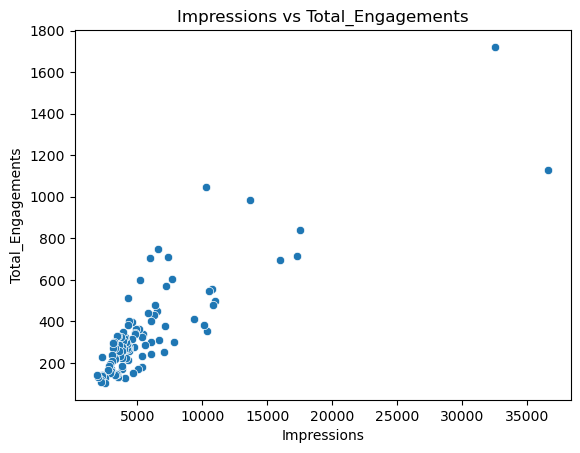

In [30]:
sns.scatterplot(data=df,x='Impressions',y='Total_Engagements')
plt.title('Impressions vs Total_Engagements')
plt.xlabel('Impressions')
plt.ylabel('Total_Engagements')
plt.show()

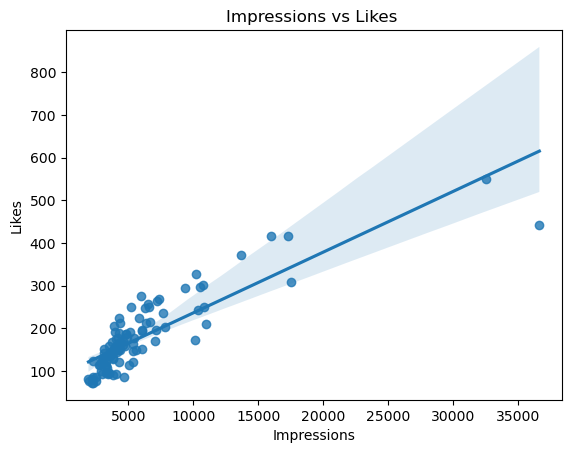

In [31]:
sns.regplot(data=df,x='Impressions',y='Likes')
plt.title('Impressions vs Likes ')
plt.xlabel('Impressions')
plt.ylabel('Likes')
plt.show()

- The more times a post is seen, the more likes and engagement it receives.

In [32]:
sources = ['From_Home', 'From_Hashtags', 'From_Explore', 'From_Other']
source_sums = df[sources].sum()

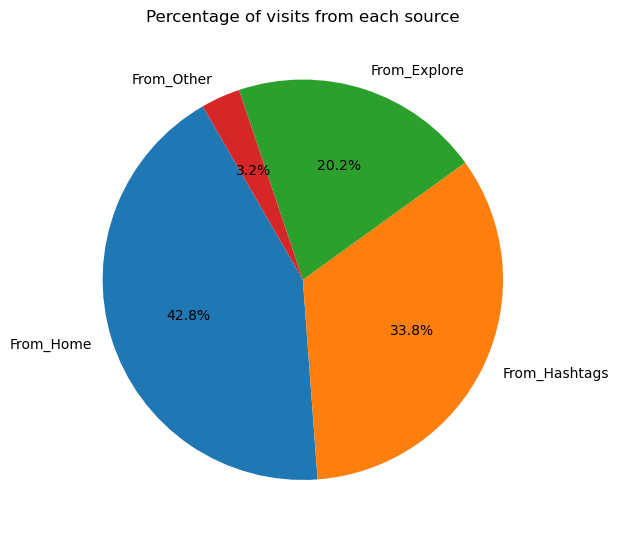

In [33]:
plt.figure(figsize=(7,6.5))
plt.pie(source_sums, labels=source_sums.index, autopct='%.1f%%', startangle=120)
plt.title('Percentage of visits from each source')
plt.show()

- the best source of Impressions is From home and Hashtags

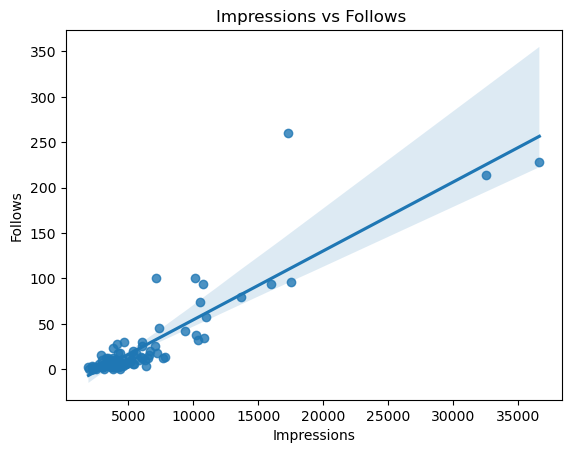

In [34]:
sns.regplot(data=df,x='Impressions',y='Follows')
plt.title('Impressions vs Follows ')
plt.xlabel('Impressions')
plt.ylabel('Follows')
plt.show()

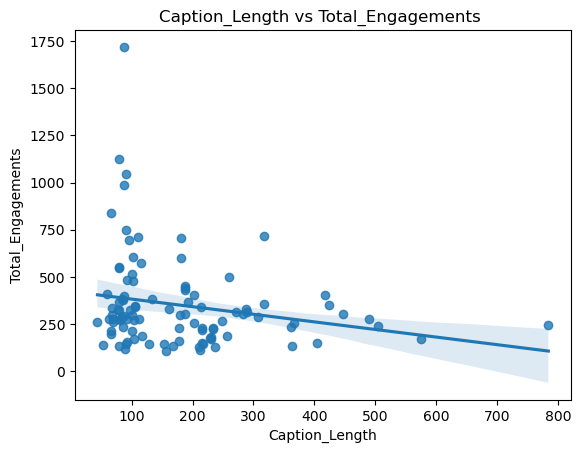

In [35]:
# Does caption length influence engagement?
sns.regplot(data=df,x='Caption_Length',y='Total_Engagements')
plt.title('Caption_Length vs Total_Engagements ')
plt.xlabel('Caption_Length')
plt.ylabel('Total_Engagements')
plt.show()

- It does not affect, but rather reduces the number of reactions.

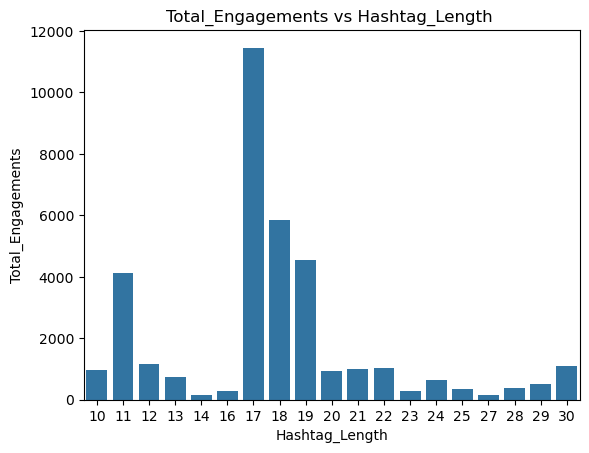

In [36]:
#Does the length of a hashtag affect engagement with a post?
sns.barplot(data=df,x='Hashtag_Length',y='Total_Engagements',estimator='sum',errorbar=None)
plt.title('Total_Engagements vs Hashtag_Length ')
plt.xlabel('Hashtag_Length')
plt.ylabel('Total_Engagements')
plt.show()

In [37]:
df.corr(numeric_only=True)

,Impressions,From_Home,From_Hashtags,From_Explore,From_Other,Saves,Comments,Shares,Likes,Profile_Visits,Follows,Total_Engagements,Engagement_Rate,Hashtag_Length,Caption_Length
Impressions,1.000000,0.850622,0.549246,0.894482,0.583416,0.794731,-0.005064,0.658159,0.855686,0.761633,0.889181,0.843264,-0.253803,-0.285716,-0.098839
From_Home,0.850622,1.000000,0.171849,0.805609,0.560149,0.786382,0.002763,0.693729,0.697192,0.537245,0.676961,0.783897,-0.002421,-0.206597,-0.158890
From_Hashtags,0.549246,0.171849,1.000000,0.177493,0.210705,0.285209,0.213391,0.211964,0.667107,0.692433,0.549309,0.430704,-0.319435,-0.237133,0.098583
From_Explore,0.894482,0.805609,0.177493,1.000000,0.490258,0.769341,-0.152720,0.643606,0.655724,0.530046,0.795342,0.754091,-0.214656,-0.196105,-0.144135
From_Other,0.583416,0.560149,0.210705,0.490258,1.000000,0.335213,-0.081073,0.155730,0.388314,0.627791,0.537115,0.359117,-0.205268,-0.378977,-0.146820
Saves,0.794731,0.786382,0.285209,0.769341,0.335213,1.000000,-0.003695,0.874004,0.843395,0.377424,0.647585,0.981266,0.260789,-0.269993,-0.228551
Comments,-0.005064,0.002763,0.213391,-0.152720,-0.081073,-0.003695,1.000000,0.012697,0.163383,0.136590,-0.029298,0.068998,0.162363,-0.009459,0.065649
Shares,0.658159,0.693729,0.211964,0.643606,0.155730,0.874004,0.012697,1.000000,0.718790,0.265460,0.517278,0.861283,0.265817,-0.088770,-0.241143
Likes,0.855686,0.697192,0.667107,0.655724,0.388314,0.843395,0.163383,0.718790,1.000000,0.642658,0.758234,0.930257,0.087520,-0.329237,-0.157874
Profile_Visits,0.761633,0.537245,0.692433,0.530046,0.627791,0.377424,0.136590,0.265460,0.642658,1.000000,0.852748,0.483198,-0.372408,-0.300904,-0.041951


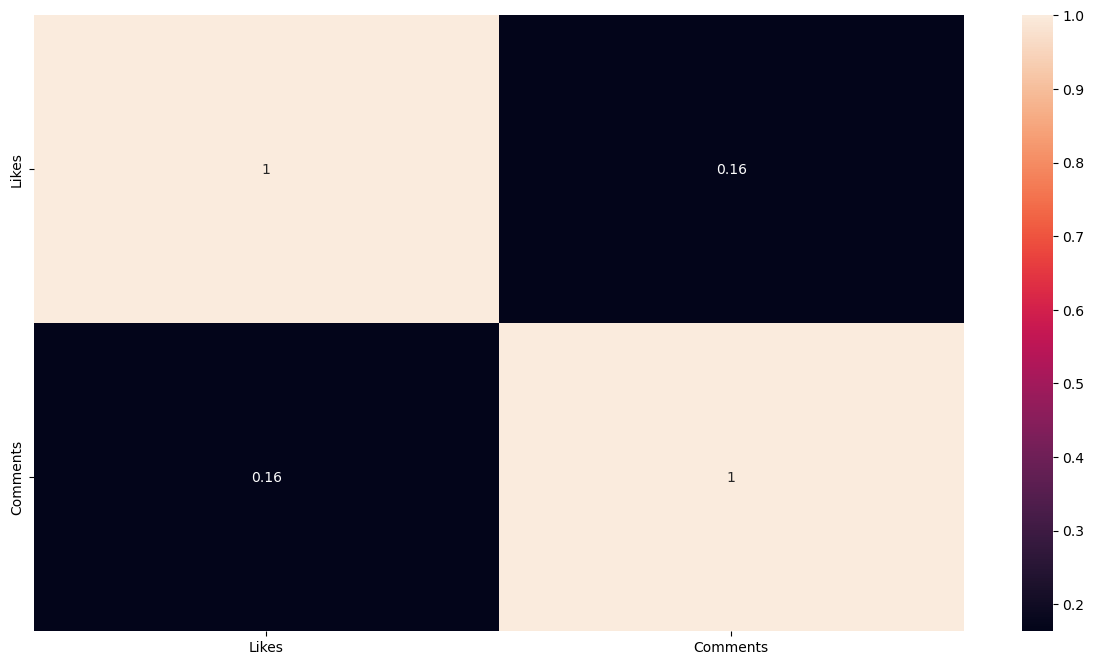

In [38]:
#What is the relationship between likes and comments?
plt.figure(figsize=(15,8))
sns.heatmap(df[['Likes','Comments']].corr(numeric_only=True), annot=True)
plt.show()

- The more likes a post receives, the more comments it receives – a generally positive correlation.

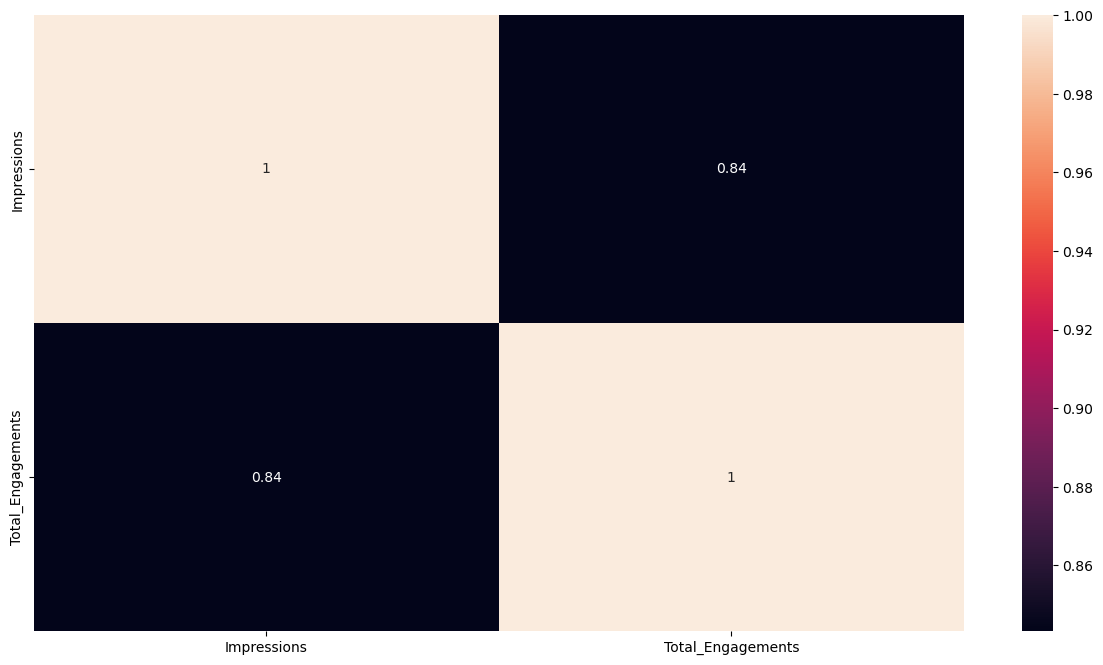

In [39]:
plt.figure(figsize=(15,8))
sns.heatmap(df[['Impressions','Total_Engagements']].corr(numeric_only=True), annot=True)
plt.show()

- The more times a post is displayed, the more interaction it receives.

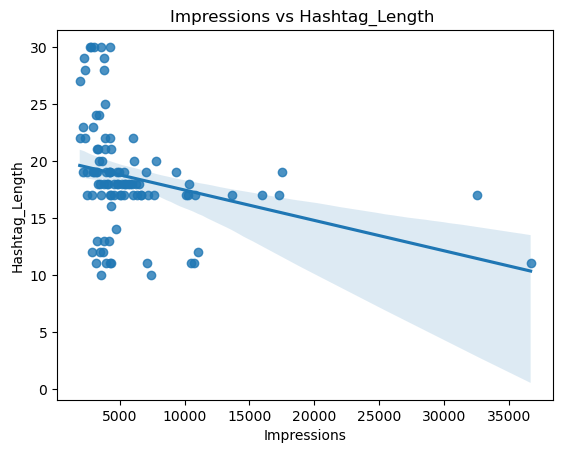

In [40]:
sns.regplot(data=df,x='Impressions',y='Hashtag_Length')
plt.title('Impressions vs Hashtag_Length ')
plt.xlabel('Impressions')
plt.ylabel('Hashtag_Length')
plt.show()

- The length of the hashtag has an inverse effect on the number of interactions.

<Figure size 1600x1600 with 0 Axes>

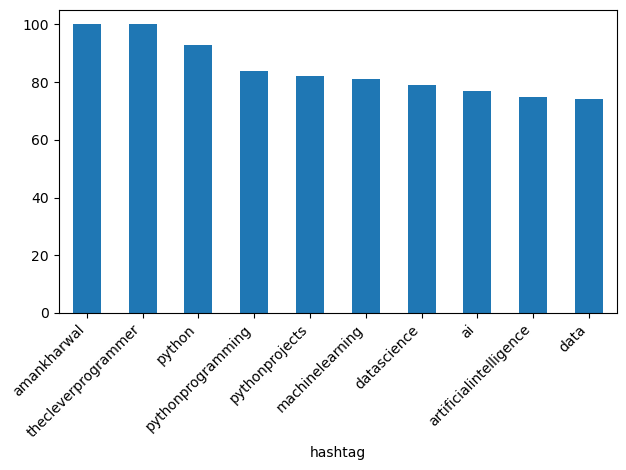

In [41]:
# top 5 Hashtags used
plt.figure(figsize=(16,16))
tags_count_df.plot(kind ='bar',x='hashtag',y='count', legend=False )
plt.xticks(rotation=45,ha='right')
plt.tight_layout()  
plt.show()

## Top Performing Hashtags
- amankharwal (100 times)
- thecleverprogrammer (100 times)
- python (93 times)
- pythonprogramming (84 times)
- pythonprojects (82 times)

In [42]:
df.columns

Index(['Impressions', 'From_Home', 'From_Hashtags', 'From_Explore',
       'From_Other', 'Saves', 'Comments', 'Shares', 'Likes', 'Profile_Visits',
       'Follows', 'Caption', 'Hashtags', 'Total_Engagements',
       'Engagement_Rate', 'Hashtag_Length', 'Caption_Length',
       'hashtags_clean'],
      dtype='object')

In [43]:
#Which posts receive the highest number of likes?
top10 = df.nlargest(10, "Likes")


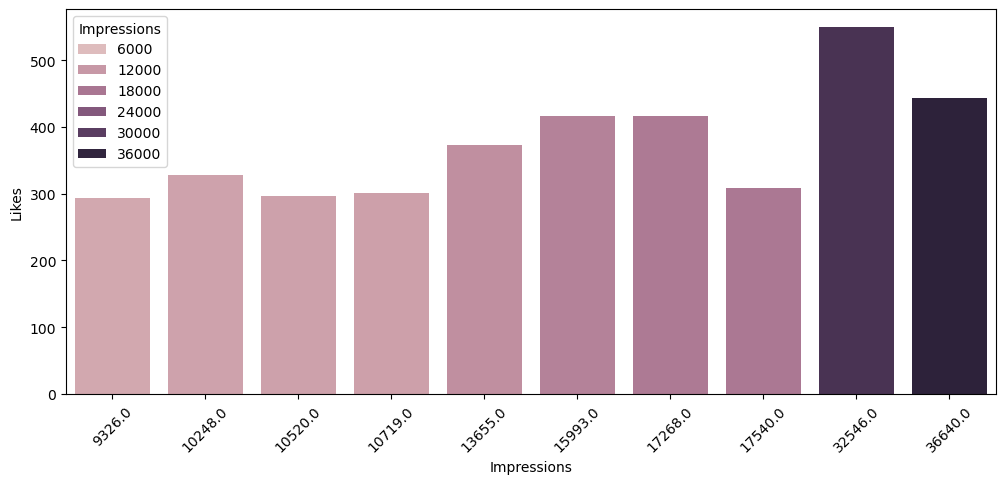

In [44]:
plt.figure(figsize=(12,5))
sns.barplot(data=df, x=top10['Impressions'], y=top10['Likes'], hue='Impressions',
           estimator='sum', errorbar=None);
plt.xticks(rotation = 45)
plt.show()

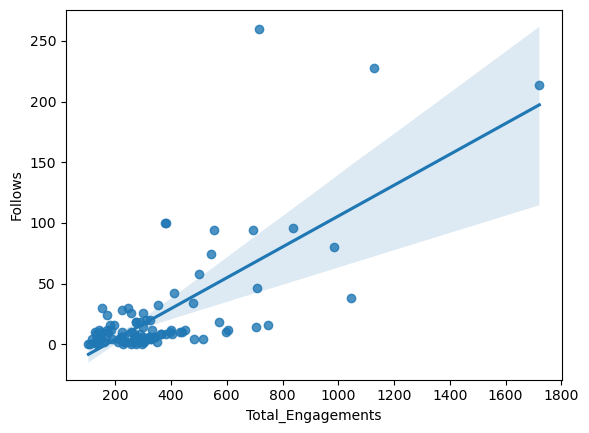

In [45]:
#What is the relationship between Total_Engagements and follows ?
sns.regplot(data=df,x='Total_Engagements',y='Follows')
plt.show()

In [46]:
df.to_csv("Instagram_Data_analysed.csv",index = False)

## Conclusion
---
the analysis shows that an increase in post impressions leads directly to higher engagement, including more likes and comments. The strongest sources of impressions are From Home and Hashtags, which means improving visibility on the home feed and using effective hashtags produces the best results.
It was also found that caption length does not boost engagement—in fact, longer captions may slightly reduce reactions. Additionally, there is a clear positive correlation between likes and comments: when likes increase, comments tend to increase as well.
Regarding hashtags, long or overly complex hashtags reduce engagement, while short, clear hashtags perform better. The top-performing hashtags were:
amankharwal (100)
thecleverprogrammer (100)
python (93)
pythonprogramming (84)
pythonprojects (82)

### Final Tip
- Focus on:
---  
Using short, effective hashtags
Increasing post visibility on the Home feed
Writing concise and clear captions
Over time, track which hashtags consistently drive engagement and reuse them strategically.